# Modular Multi-Hinge Spine Design

## Project Description
This notebook generates manufacturing files for a five-layer laminate robotic spine. 

### Code Structure
To make this project suitable for a software portfolio, the code is organized into **modular functions** rather than a linear script. Each section below:
1.  **Defines a function** to handle a specific manufacturing step (e.g., `generate_hinges`).
2.  **Executes the function** using the configuration settings.
3.  **Visualizes the output** immediately to verify the geometry.

In [1]:
import os
import foldable_robotics.dxf as frd
import foldable_robotics as fr
import foldable_robotics.manufacturing as frm
import foldable_robotics.parts.castellated_hinge2 as frc
from foldable_robotics.layer import Layer
from foldable_robotics.laminate import Laminate
import shapely.geometry as sg
import dxfv2 as dv

# ==========================================
# 1. CONFIGURATION (The Control Center)
# ==========================================
# Centralized settings for easy tuning.
CONFIG = {
    "input_file": "dxf/input/jensen-leg.dxf",
    "output_folder": "dxf/output",
    "thickness": 1.0,  # Total laminate thickness (mm)
    "fold_angle": 120,  # Max rotation for flexible joints
    "structure_angle": 90,  # Angle for fixed structural folds
    "num_layers": 5,  # 5-layer laminate
    "is_adhesive": [
        False,
        True,
        False,
        True,
        False,
    ],  # Rigid-Adhesive-Flex-Adhesive-Rigid
    "kerf": 0.05,  # Laser cutter beam width
    "jig_diameter": 5,  # Alignment pin size
    "jig_spacing": 10,  # Grid size for pins
    "support_width": 2,  # Width of the webbing
    "bridge_thickness": 0.5,  # Thickness of holding tabs
    "arc_approx": 10,  # Curve resolution
    "bounding_box_padding": 10,  # Padding around the sheet
}

# Indices identifying specific lines in the DXF
HINGE_INDICES = [10, 11, 12, 13, 14, 15, 16, 25, 34]
STRUCTURE_INDICES = [
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    17,
    18,
    19,
    20,
    21,
    22,
    23,
    24,
    26,
    27,
    28,
    29,
    30,
    31,
    32,
    33,
]


def setup_environment():
    fr.display_height = 300
    fr.resolution = 4
    if not os.path.exists(CONFIG["output_folder"]):
        os.makedirs(CONFIG["output_folder"])
    print(f"Environment ready. Output will be saved to: {CONFIG['output_folder']}")


setup_environment()


Environment ready. Output will be saved to: dxf/output


## 2. Geometry Extraction
This module creates the `extract_body_geometry` function. It reads the raw DXF entities (lines, polylines, circles) and converts them into clean Shapely polygons. 

It applies **boolean subtraction** (like a cookie cutter) to remove holes and cuts from the main body.

Extracting geometry...


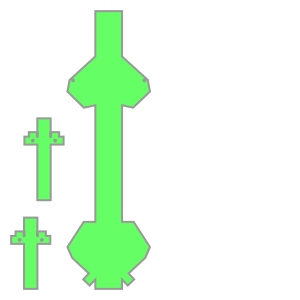

In [2]:
def extract_body_geometry(filename):
    """Reads body, holes, and cuts to create the base Layer."""
    # 1. Read Body Outline
    body_verts = dv.read_lwpolylines(
        filename, layer="body", arc_approx=CONFIG["arc_approx"]
    )
    body_polys = [sg.Polygon(pts).buffer(0) for pts in body_verts]
    body_layer = Layer(*body_polys)

    # 2. Read Holes (Polygons + Circles)
    hole_verts = dv.read_lwpolylines(
        filename, layer="holes", arc_approx=CONFIG["arc_approx"]
    )
    circle_specs = dv.read_circles(filename, layer="holes")
    circle_polys = [sg.Point(c).buffer(r, quad_segs=16) for c, r in circle_specs]
    hole_layer = Layer(*[sg.Polygon(pts) for pts in hole_verts + circle_polys])

    # 3. Read Cuts (Lines)
    cut_verts = dv.read_lines(filename, layer="cuts")
    cut_layer = Layer(*[sg.LineString(pts) for pts in cut_verts])
    cut_layer <<= 0.5  # Give cuts width so they can be subtracted

    # 4. Subtract Holes and Cuts from Body
    body_layer -= hole_layer
    body_layer -= cut_layer
    return body_layer


def extract_joints(filename, body_layer):
    """Separates joint lines into Hinge (flexible) and Structure (rigid)."""
    joint_vertices = dv.read_lines(filename, layer="joints")

    hinge_vertices = [joint_vertices[i] for i in HINGE_INDICES]
    structure_vertices = [joint_vertices[i] for i in STRUCTURE_INDICES]

    hinge_layer = Layer(*[sg.LineString(items) for items in hinge_vertices])
    structure_layer = Layer(*[sg.LineString(items) for items in structure_vertices])

    # Trim lines to ensure they don't extend past the body
    hinge_layer &= body_layer
    structure_layer &= body_layer

    return (
        [list(item.coords) for item in hinge_layer.geoms],
        [list(item.coords) for item in structure_layer.geoms],
    )


# --- EXECUTION ---
print("Extracting geometry...")
body = extract_body_geometry(CONFIG["input_file"])
hinge_lines, struct_lines = extract_joints(CONFIG["input_file"], body)

# VISUALIZATION: Show the clean body geometry
body


## 3. Hinge Generation
This module calculates the specific castellated pattern required for the hinges. 

It uses `map_line_stretch` to stretch the hinge pattern along the specific lines extracted from the DXF.

Generating hinge patterns...


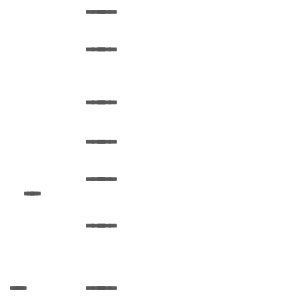

In [3]:
def generate_hinge_patterns(hinge_coords, struct_coords):
    """Generates castellated hinge geometry and maps it to the lines."""

    # 1. Calculate Widths
    w_deg, g_deg = frm.castellated_hinge_width(
        CONFIG["fold_angle"], CONFIG["thickness"]
    )
    w_str, g_str = frm.castellated_hinge_width(
        CONFIG["structure_angle"], CONFIG["thickness"]
    )

    # 2. Generate Templates
    deg_pattern = frc.generate(g_deg, w_deg)
    str_pattern = frc.generate(g_str, w_str)

    lam_deg = Layer().to_laminate(len(deg_pattern))
    lam_str = Layer().to_laminate(len(str_pattern))

    # 3. Map Templates to Lines
    all_deg_hinges = [
        deg_pattern.map_line_stretch((0, 0), (1, 0), p1, p2) for p1, p2 in hinge_coords
    ]
    all_str_hinges = [
        str_pattern.map_line_stretch((0, 0), (1, 0), p1, p2) for p1, p2 in struct_coords
    ]

    return lam_deg.unary_union(*all_deg_hinges), lam_str.unary_union(*all_str_hinges)


# --- EXECUTION ---
print("Generating hinge patterns...")
hinge_geoms, struct_geoms = generate_hinge_patterns(hinge_lines, struct_lines)

# VISUALIZATION: Show the castellated hinges
hinge_geoms


## 4. Laminate Assembly
This module builds the physical stack-up. It creates a 5-layer laminate, subtracts the hinge material, and adds "bridges" (support tabs) to the structural layers.

Assembling laminate...


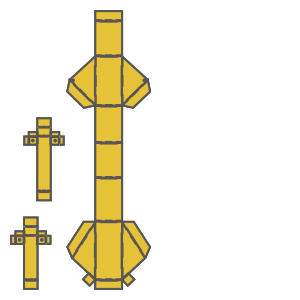

In [4]:
def assemble_device(body_layer, hinge_geoms, struct_geoms, filename):
    # 1. Stack Layers
    device = Laminate(body_layer, body_layer, body_layer, body_layer, body_layer)
    device -= hinge_geoms
    device -= struct_geoms

    # 2. Create Support Bridges
    bridges = dv.read_lines(filename, layer="bridge")
    bridges_layer = Layer(*[sg.LineString(item) for item in bridges])
    bridges_layer <<= CONFIG["bridge_thickness"]

    # Bridges exist on top (0) and bottom (4) structural layers
    bridges_lam = Laminate(
        bridges_layer, bridges_layer, Layer(), bridges_layer, bridges_layer
    )

    supported_device = device | bridges_lam

    # 3. Cleanup Artifacts
    diff = supported_device - device
    removal = frm.cleanup(diff, 0.1)
    removal = frm.keepout_laser(removal)

    return device - removal


# --- EXECUTION ---
print("Assembling laminate...")
final_device = assemble_device(body, hinge_geoms, struct_geoms, CONFIG["input_file"])

# VISUALIZATION: Show the full 5-layer device
final_device


## 5. Web & Scrap Generation
This module prepares the manufacturing sheet. It calculates the **Web** (the waste material we peel off) and the **Alignment Jigs**.

Visualizing this step is crucial to ensure the device is properly connected to the frame.

Generating web and supports...


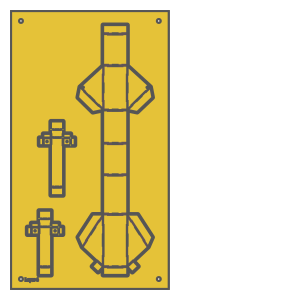

In [5]:
def generate_web_and_jigs(device):
    # 1. Bounding Box & Grid Alignment
    (x1, y1), (x2, y2) = device.bounding_box_coords()
    w, h = device.get_dimensions()

    w_grid = (
        round(w / CONFIG["jig_spacing"]) * CONFIG["jig_spacing"]
        + CONFIG["jig_spacing"]
        + CONFIG["support_width"]
    )
    h_grid = (
        round(h / CONFIG["jig_spacing"]) * CONFIG["jig_spacing"]
        + CONFIG["jig_spacing"]
        + CONFIG["support_width"]
    )

    # Center the device
    x1 -= (w_grid - w) / 2
    y1 -= (h_grid - h) / 2
    x2 += (w_grid - w) / 2
    y2 += (h_grid - h) / 2

    # 2. Create Jig Holes
    points = [sg.Point(x1, y1), sg.Point(x2, y1), sg.Point(x1, y2), sg.Point(x2, y2)]
    holes_layer = Layer(*points)
    holes_layer <<= CONFIG["jig_diameter"] / 2
    alignment_holes = holes_layer.to_laminate(CONFIG["num_layers"])

    # 3. Create Sheet & Web
    sheet_layer = (holes_layer << CONFIG["bounding_box_padding"]).bounding_box()
    sheet = sheet_layer.to_laminate(CONFIG["num_layers"])

    layer_id = frm.build_layer_numbers(
        CONFIG["num_layers"], text_size=CONFIG["jig_diameter"]
    ).simplify(0.2)

    # Calculate what needs to be removed (The Web)
    removable = frm.calculate_removable_scrap(
        device, sheet, CONFIG["support_width"], CONFIG["is_adhesive"]
    )
    web = (
        removable
        - alignment_holes
        - layer_id.translate(
            x1 + CONFIG["jig_diameter"], y1 - CONFIG["jig_diameter"] / 2
        )
    )

    return web, sheet, alignment_holes


# --- EXECUTION ---
print("Generating web and supports...")
web, sheet, holes = generate_web_and_jigs(final_device)

# VISUALIZATION: Show the Web (Blue) holding the Device (Clear/Black)
supported_design = web | final_device
supported_design


## 6. Export to DXF
Finally, we separate the design into **First Pass** (fine details) and **Final Cut** (outer boundary release) and save them.

In [6]:
def export_manufacturing_files(device, web, sheet):
    # Calculate Laser Keepout (Safety buffer)
    keepout = frm.keepout_laser(device)
    support = frm.support(
        device, frm.keepout_laser, CONFIG["support_width"], CONFIG["support_width"] / 2
    )
    supported_design = web | device | support

    # --- Export 1: First Pass ---
    # Arrange layers side-by-side for cutting
    w, h = supported_design.get_dimensions()
    p0, p1 = supported_design.bounding_box_coords()

    rigid_layer = supported_design[0] | (supported_design[-1].translate(w + 5, 0))

    # Mirror top adhesive so it flips correctly during assembly
    l4 = supported_design[3].scale(-1, 1)
    p2, p3 = l4.bounding_box_coords()
    l4 = l4.translate(p0[0] - p2[0] + w + 5, p0[1] - p2[1])
    adhesive_layer = supported_design[1] | l4

    first_pass = Laminate(rigid_layer, adhesive_layer, supported_design[2])
    fp_path = os.path.join(CONFIG["output_folder"], "first_pass")
    first_pass.export_dxf(fp_path)
    print(f"Exported: {fp_path}.dxf")

    # --- Export 2: Final Cut ---
    final_cut = sheet - keepout
    final_cut = final_cut[0]
    fc_path = os.path.join(CONFIG["output_folder"], "final_cut")
    final_cut.export_dxf(fc_path)
    print(f"Exported: {fc_path}.dxf")


# --- EXECUTION ---
print("Exporting files...")
export_manufacturing_files(final_device, web, sheet)
print("Done.")


Exporting files...
Exported: dxf/output/first_pass.dxf
Exported: dxf/output/final_cut.dxf
Done.
